In [329]:
# ==========================================
# 1. Standard Library Imports
# ==========================================
import os
import sys
import csv
import time
import pickle
import random
import warnings
import itertools
import textwrap
import re
from collections import Counter
from joblib import Parallel, delayed
warnings.filterwarnings('ignore', message="The least populated class in y has only.*")
os.environ['PYTHONWARNINGS'] = 'ignore:The least populated class in y has only.*:UserWarning'
from datetime import datetime

# ==========================================
# 2. Third-Party Scientific Imports
# ==========================================
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
import scipy.linalg as linalg
import scipy.optimize as optimize
import scipy.fft as fft
import scipy.signal as signal
from scipy.interpolate import interp1d
from scipy.stats import pearsonr, skewnorm
import heapq

# Specialized Science Toolkits
import pywt
import pycwt as wavelet
import emd
from eofs.standard import Eof
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer

# Machine Learning (Scikit-Learn)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures, normalize
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedShuffleSplit, 
    cross_val_score, KFold, LeaveOneOut, StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, 
    roc_curve, accuracy_score, classification_report, mean_squared_error
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn import tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ==========================================
# 3. Visualization & Plotting
# ==========================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
import seaborn as sns
import imgkit
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import BoundaryNorm
from colorama import Fore, Back, Style

# Geospatial Plotting
import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.util import add_cyclic_point

# ==========================================
# 4. Configuration & Local Modules
# ==========================================
warnings.filterwarnings('ignore')
sns.set_theme() # Optional: sets a cleaner default style for plots

# Define Paths
HURDAT_CODE_PATH = '/Users/jackskari/Desktop/NCSU_Research/Modularized_Code/'
DATA_FILE_PATH = "/Users/jackskari/Desktop/NCSU_Research/New_Data_2025/hurr2025.csv"

# Dynamic import of local module
if HURDAT_CODE_PATH not in sys.path:
    sys.path.append(HURDAT_CODE_PATH)

try:
    import ReadHurdatData
except ImportError:
    print(f"Error: Could not find ReadHurdatData at {HURDAT_CODE_PATH}")

# ==========================================
# 5. Data Loading & Initial Processing
# ==========================================
df = pd.read_csv(DATA_FILE_PATH)

# Load Near-Land Data
(nearmod_df, nearseasonal_ace, nearseasonal_num, nearseasonal_dur, 
 nearseasonal_apsm, nearseasonal_ap6h, nearseasonal_avdur, nearmonthly_ace, 
 nearseasonal_avmaxwind, nearseasonal_hurr, nearseasonal_mh, nearseasonal_hu, 
 nearseasonal_mjhu, yearz) = ReadHurdatData.hurdatclean(df, 1, 12, landmask=1, nearland=2)

# Load Standard Seasonal Data
(mod_df, seasonal_ace, seasonal_num, seasonal_dur, 
 seasonal_apsm, seasonal_ap6h, seasonal_avdur, monthly_ace, 
 seasonal_avmaxwind, seasonal_hurr, seasonal_mh, seasonal_hu, 
 seasonal_mjhu, yearz) = ReadHurdatData.hurdatclean(df, 1, 12)

# Slicing Indices (100+)
yearzz = np.asarray(yearz[100:])
ace_prime = seasonal_ace[100:]
num_prime = seasonal_num[100:]

nearace_prime = nearseasonal_ace[100:]
nearnum_prime = nearseasonal_num[100:]

# Load in Data and Set Choices for RF

In [330]:
# ==========================================
# 1. Categorization Functions
# ==========================================

def get_activity_categories(data_list, reference_list, year_labels):
    """
    Categorizes years into High, Mid, or Low activity based on quartiles.
    
    Args:
        data_list: The values to categorize.
        reference_list: The baseline values used to calculate percentiles (e.g., a training period).
        year_labels: List of years corresponding to the data_list.
    """
    q1 = np.percentile(reference_list, 25)
    q3 = np.percentile(reference_list, 75)

    # Use NumPy select for fast, readable conditional mapping
    conditions = [
        (data_list <= q1),
        (data_list >= q3)
    ]
    scores = [0, 2] # 0: Low, 2: High
    
    # Default is 1 (Mid)
    final_scores = np.select(conditions, scores, default=1)
    
    # Filter years into separate lists for research analysis
    low  = [year_labels[i] for i, s in enumerate(final_scores) if s == 0]
    mid  = [year_labels[i] for i, s in enumerate(final_scores) if s == 1]
    high = [year_labels[i] for i, s in enumerate(final_scores) if s == 2]

    return high, mid, low, final_scores


def get_extended_categories(data_list, reference_list, year_labels, bound=2.0):
    """
    Categorizes years into Hyperactive, High, Mid, or Low activity.
    """
    q1 = np.percentile(reference_list, 33)
    q3 = np.percentile(reference_list, 67)
    high_threshold = bound * np.median(reference_list)

    conditions = [
        (data_list < q1),                               # Low
        (data_list >= q3) & (data_list <= high_threshold), # High
        (data_list > high_threshold)                    # Very High (Hyperactive)
    ]
    scores = [0, 2, 3] # 0:Low, 2:High, 3:Very High
    
    final_scores = np.select(conditions, scores, default=1) # Default 1: Mid

    # Organize years
    low  = [year_labels[i] for i, s in enumerate(final_scores) if s == 0]
    mid  = [year_labels[i] for i, s in enumerate(final_scores) if s == 1]
    high = [year_labels[i] for i, s in enumerate(final_scores) if s == 2]
    v_high = [year_labels[i] for i, s in enumerate(final_scores) if s == 3]

    return v_high, high, mid, low, final_scores

# ==========================================
# 2. Path Configuration & Data Loading
# ==========================================

BASE_DIR = "/Users/jackskari/Desktop/NCSU_Research/ML_Data_Classes"

# Load Pickled Data
with open(f"{BASE_DIR}/truedata1950-2025.pkl", 'rb') as f:
    pure_data = pickle.load(f)

# Load DataFrames and clean "Unnamed" columns immediately


ace_df = pd.read_csv(f"{BASE_DIR}/clusteredace.csv", index_col=0)
coast_ace_df = pd.read_csv(f"{BASE_DIR}/clusteredcoastace.csv", index_col=0)

with open(f"{BASE_DIR}/cpcclass.pkl", 'rb') as f:
    activity_class = pickle.load(f)


# ==========================================
# 3. Variable Initialization
# ==========================================

# Feature Names
feature_names = ['amm', 'amo', 'ao', 'censo', 'dm', 'epo', 'ggst', 'ngst', 'sgst',
    'mdrolr', 'mdrslp', 'mdrsst', 'nao', 'pdo', 'pna', 'qbo', 'sfi', 'soi', 'tni', 
    'tna', 'tsa', 'whwp', 'wpi', 'nino12', 'nino3', 'nino34', 'nino4', 'mei', 'roni', 
    'sahel', 'mdru200', 'mdru850', 'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'mdrt200', 'gomolr', 'gomslp', 'rhsal', 'nino34_forecast'
]

# Extract activity class components
(hyper_years, above_years, average_years, below_years, 
 score_data, actualscore) = activity_class[:6]

activity_bins = [below_years, average_years, above_years, hyper_years]
type_labels = ["Below Average", "Average", "Above Average", "Hyperactive"]

# ==========================================
# 4. Scenario Logic (Coastal vs General)
# ==========================================

COAST_MODE = 1
features = ace_df
class_type = 'CPC'

if COAST_MODE == 1:
    vhigh, high, mid, low, scores = get_extended_categories(
        nearace_prime, 
        nearace_prime[:70], 
        year_labels=yearzz, 
        bound=2
    )
    features = coast_ace_df
    actualscore = np.asarray(scores)
    class_type = 'CHACE'
# Metadata for plotting/exports
months_order = ['JUN','JUL','AUG','SEP','OCT','NOV','DEC','JAN','FEB','MAR','APR','MAY']

climperiod=30
if climperiod==30:
    startyear=0
else:
    startyear=0
typecast = np.array([0,1,2,3])

paramfeeder=None

# Random Forest Model Set Up

In [331]:
inseason=['JUN','JUL','AUG','SEP','OCT','NOV']
neomonth=['DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']
ronidat=pure_data['roni'][inseason].iloc[1:]
hotneu=[]
coldneu=[]
trueneu=[]

recentyearzz=yearzz[30:]
for i in range(75):
    encount = sum(x > 0.5 for x in ronidat.iloc[i].values)
    lacount = sum(x < -0.5 for x in ronidat.iloc[i].values)

    borderencount = sum(x > 0.3 for x in ronidat.iloc[i].values)
    borderlacount = sum(x < -0.3 for x in ronidat.iloc[i].values)
    if (encount >= 3): #or (borderencount >= 3):
        hotneu.append(i)
    elif (lacount >= 3): #or (borderlacount >= 3):
        coldneu.append(i)
    else:
        trueneu.append(i)


start_time = time.time()
os.environ['PYTHONWARNINGS'] = 'ignore:The least populated class in y has only.*:UserWarning'
# ==========================================
# 1. Statistical Utility Functions
# ==========================================

def calculate_mode_params(param_list):
    """Finds the most frequent hyperparameter set from a list of dictionaries."""
    keys = param_list[0].keys()
    return {
        k: Counter([d[k] for d in param_list]).most_common(1)[0][0]
        for k in keys
    }

def calculate_likelihood(probabilities):
    """Calculates the geometric mean (likelihood) of a probability array."""
    return np.prod(probabilities) ** (1 / len(probabilities))

def align_class_probabilities(y_proba, model_classes, all_classes):
    """Maps model predicted probabilities to the full set of global classes."""
    full_probs = np.zeros(len(all_classes))
    for i, cls in enumerate(model_classes):
        full_probs[int(cls)] = y_proba[i]
    return full_probs

def get_climatology_bounds(year, base_year, clim_len=30, step=10):
    """Calculates the start and end years for a climatology reference block."""
    block_start = year - ((year - (base_year + clim_len)) % step)
    clim_start = block_start - clim_len
    clim_end = block_start - 1
    return clim_start, clim_end

def run_sliding_window_cv(
    X_all, y_all, typecast, clim_period, start_year_idx, base_year, 
    param_input, 
    grid_interval=5, enso_metadata=ensodata
):
    is_search_mode = isinstance(next(iter(param_input.values())), list)
    n_samples = len(y_all)
    end_idx = n_samples - clim_period - 10
    
    # --- HELPER: Process a single window ---
    def process_window(test_idx):
        current_year = test_idx + clim_period + base_year
        clim_start, clim_end = get_climatology_bounds(current_year, base_year, clim_len=clim_period)
        
        train_start_idx = clim_start - base_year
        train_end_idx = clim_end - base_year + 1

        X_train, y_train = X_all[train_start_idx:train_end_idx], y_all[train_start_idx:train_end_idx]
        X_test = X_all[test_idx + clim_period : test_idx + clim_period + 1]
        y_test = y_all[test_idx + clim_period]

        # Climatology Baseline
        counts = np.bincount(y_train, minlength=len(typecast))
        clim_baseline_probs = counts / len(y_train)
        test_clim_prob = clim_baseline_probs[y_test]
        # Weigh Sample Years Based on ENSO Phase
        window_years = range(clim_start, clim_end + 1)
        target_weight_type = "neutral"
        if current_year in [yearzz[i] for i in hotneu]: target_weight_type = "el_nino"
        if current_year in [yearzz[i] for i in coldneu]: target_weight_type = "la_nina"
        dynamic_weights = []
        for yr in window_years:
            weight = 1.0
            if target_weight_type == "el_nino" and yr in [yearzz[i] for i in hotneu]:
                weight = 2.0
            elif target_weight_type == "la_nina" and yr in [yearzz[i] for i in coldneu]:
                weight = 2.0
            elif target_weight_type == "neutral" and yr in [yearzz[i] for i in trueneu]:
                weight = 1.0 # Optional: slight boost to other neutral years
            dynamic_weights.append(weight)
        
        sample_weights = np.array(dynamic_weights)

        # Hyperparameter Search (Note: n_jobs=1 here because the window is parallelized)
        if is_search_mode and (test_idx % grid_interval == 0):
            grid = GridSearchCV(
                RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
                param_input, cv=3, n_jobs=1, scoring="accuracy"
            )
            grid.fit(X_train, y_train, sample_weight=sample_weights)
            best_params = grid.best_params_
        else:
            # If search mode but not on interval, or fixed mode
            # In a parallel loop, we can't easily "cache" across threads without complexity,
            # so we use the fixed input or default to the provided params.
            best_params = {k: v[0] if isinstance(v, list) else v for k, v in param_input.items()}

        # Model Training

        rf = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=1)
        rf.fit(X_train, y_train, sample_weight=sample_weights)

        y_prob_raw = rf.predict_proba(X_test)[0]
        y_prob_full = align_class_probabilities(y_prob_raw, rf.classes_, typecast)
        forecast_score = y_prob_full[y_test]

        # Return all necessary metrics for this window
        h_score = (forecast_score - test_clim_prob) / (1 - test_clim_prob) if test_clim_prob != 0 else 0
        
        return h_score, forecast_score, test_clim_prob, rf.feature_importances_, best_params

    # --- EXECUTE IN PARALLEL ---
    # n_jobs=-1 uses all available CPU cores
    results = Parallel(n_jobs=-1)(
        delayed(process_window)(idx) for idx in range(start_year_idx, end_idx)
    )

    # Unpack results
    skill_scores, forecast_probs, climatology_probs, feature_importances, best_params_history = zip(*results)




    final_mean_importances=np.mean(feature_importances,axis=0)

    # --- AGGREGATE ---
    avg_fore_likelihood = calculate_likelihood(np.array(forecast_probs))
    avg_clim_likelihood = calculate_likelihood(np.array(climatology_probs))
    total_skill = (avg_fore_likelihood - avg_clim_likelihood) / (1 - avg_clim_likelihood)
    
    return {
        "skill": total_skill,
        "importances": final_mean_importances,
        "params": list(best_params_history)
    }

def run_feature_selection(features_df, y_labels, typecast, clim_period, start_year, base_year, param_grid):
    current_features = features_df.columns.tolist()
    history = {"feature_sets": [], "skills": [], "params": []}

    while len(current_features) > 4:
        X_data = features_df[current_features].values
        
        result = run_sliding_window_cv(
            X_data, y_labels, typecast, clim_period, 
            start_year, base_year, param_grid
        )

        history["feature_sets"].append(current_features.copy())
        history["skills"].append(result["skill"])
        history["params"].extend(result["params"])

        # Faster drop logic: find the single index of the lowest importance
        least_important_idx = np.argmin(result["importances"])
        removed_feature = current_features.pop(least_important_idx)
        
        print(f"Remaining: {len(current_features)} | Dropped: {removed_feature} | Skill: {result['skill']:.4f} | Time: {datetime.now().time()}")
        
    best_run_idx = np.argmax(history["skills"])
    return {
        "best_features": history["feature_sets"][best_run_idx],
        "all_params": history["params"],
        "best_skill": history["skills"][best_run_idx]
    }

# ==========================================
# 4. Final Evaluation Logic
# ==========================================

def run_final_validation(features_df, y_labels, selected_features, final_params, typecast, clim_period, base_year, split_index=35):
    """
    Performs a final validation pass, including a 'Hard Test' using a 15-year short-term training.
    """
    X_vals = features_df[selected_features].values
    y_vals = np.array(y_labels)

    forecast_likes, clim_likes = [], []
    hard_test_forecast, hard_test_clim = [], []

    for i in range(len(y_vals) - clim_period):
        year_val = i + clim_period + base_year
        clim_start, clim_end = get_climatology_bounds(year_val, base_year, clim_len=clim_period)

        X_train = X_vals[clim_start - base_year : clim_end - base_year + 1]
        y_train = y_vals[clim_start - base_year : clim_end - base_year + 1]
        X_test, y_test = X_vals[i + clim_period : i + clim_period + 1], y_vals[i + clim_period]

        # Standard Climatology
        clim_probs = np.bincount(y_train, minlength=len(typecast)) / len(y_train)
        
        rf = RandomForestClassifier(**final_params, class_weight='balanced', random_state=42)
        rf.fit(X_train, y_train)

        y_prob = align_class_probabilities(rf.predict_proba(X_test)[0], rf.classes_, typecast)
        correct_class_prob = y_prob[y_test]

        forecast_likes.append(correct_class_prob)
        clim_likes.append(clim_probs[y_test])

        # --- 15-year "Hard Test" (Short-term Climatology) ---
        if i >= split_index:
            short_train_y = y_vals[(i + clim_period) - 15 : (i + clim_period)]
            short_clim_probs = np.bincount(short_train_y, minlength=len(typecast)) / len(short_train_y)

            hard_test_forecast.append(correct_class_prob)
            hard_test_clim.append(short_clim_probs[y_test])

    # Final Skill Calculations
    main_skill = (calculate_likelihood(forecast_likes[split_index:]) - calculate_likelihood(clim_likes[split_index:])) / \
                 (1 - calculate_likelihood(clim_likes[split_index:]))

    hard_skill = (calculate_likelihood(hard_test_forecast) - calculate_likelihood(hard_test_clim)) / \
                 (1 - calculate_likelihood(hard_test_clim))

    return main_skill, hard_skill

def run_monthly_pipeline(
    features,
    actualscore,
    newmonth,
    typecast,
    climperiod,
    startyear,
    fixed_params=None,
    base_year=1951
):
    # Determine mode upfront
    # A dictionary of lists means SEARCH. A dictionary of values means FIXED.
    if fixed_params:
        # Check if the first value is a list; if not, it's fixed.
        is_search = isinstance(next(iter(fixed_params.values())), list)
        param_input = fixed_params
    else:
        is_search = True
        param_input = {
            "n_estimators": [100, 200],
            "max_depth": [2, 3, 4],
            "max_features": ["sqrt", 0.5, 1],
            "min_samples_leaf": [1, 2, 4],
            "criterion": ["gini", "entropy"]
        }

    results = []
    n = len(newmonth)
    start_time = time.time()

    for i in range(7):
        targets = newmonth[i:i+6]
        targets.append('forecast')
        wrap_month = newmonth[(i + 6) % n]
        print(f"\n===== Processing Month: {wrap_month} =====")

        selected_columns = [col for col in features.columns if any(m in col for m in targets)]
        filtered_features = features[selected_columns]
        print(f"Feature Number: {len(filtered_features.columns)}")

        # 1. Feature Selection
        fs_result = run_feature_selection(
            filtered_features, actualscore, typecast, 
            climperiod, startyear, base_year, param_input
        )

        # 2. Assign Final Params
        # Only calculate mode if we actually performed a search
        if is_search:
            final_params = calculate_mode_params(fs_result["all_params"])
        else:
            final_params = param_input

        # 3. Final Evaluation
        testH, neotestH = run_final_validation(
            filtered_features, actualscore, fs_result["best_features"],
            final_params, typecast, climperiod, base_year
        )

        results.append({
            "month": wrap_month,
            "features": fs_result["best_features"],
            "params": final_params,
            "testH": testH,
            "neotestH": neotestH
        })
        wannalook=fs_result["best_features"]
        print(f"Skill Score: {testH:.4f} | Hard Test: {neotestH:.4f}")
        print(f"Features Selected: {wannalook}")
        print(f"Time Elapsed: {time.time() - start_time:.2f} seconds")

    return results

In [ ]:
%%time
%env PYTHONWARNINGS=ignore:The least populated class in y
# To prevent the model from using things it shouldn't be
if (class_type != 'CPC') and (class_type != 'CHACE'):
    raise Exception('Choose classification set the model will use')
print(f'Classification Approach: {class_type}')
warnings.filterwarnings("ignore", message="The least populated class in y")

# Filter for parallel worker processes
os.environ['PYTHONWARNINGS'] = "ignore:The least populated class in y"
results = run_monthly_pipeline(features, actualscore, months_order, typecast, climperiod, startyear, paramfeeder)

env: PYTHONWARNINGS=ignore:The least populated class in y
Classification Approach: CHACE

===== Processing Month: DEC =====
Feature Number: 33
Remaining: 32 | Dropped: ao_OCT | Skill: 0.0311 | Time: 16:36:31.252859
Remaining: 31 | Dropped: mdrt200_OCT | Skill: 0.0204 | Time: 16:37:09.377488
Remaining: 30 | Dropped: epo_JUN | Skill: 0.0173 | Time: 16:37:46.643788
Remaining: 29 | Dropped: mdrolr_OCT | Skill: 0.0002 | Time: 16:38:22.486199
Remaining: 28 | Dropped: tsa_SEP | Skill: 0.0187 | Time: 16:38:58.662043
Remaining: 27 | Dropped: epo_SEP | Skill: 0.0272 | Time: 16:39:34.428290
Remaining: 26 | Dropped: gomu850_JUL | Skill: 0.0300 | Time: 16:40:09.981066
Remaining: 25 | Dropped: tsa_NOV | Skill: 0.0314 | Time: 16:40:46.252161
Remaining: 24 | Dropped: nino34_forecast_JUN | Skill: 0.0214 | Time: 16:41:22.840124
Remaining: 23 | Dropped: gomslp_OCT | Skill: 0.0150 | Time: 16:41:59.091852
Remaining: 22 | Dropped: nino4_JUL | Skill: 0.0301 | Time: 16:42:34.583400
Remaining: 21 | Dropped: md

# Save Data

In [280]:
# To prevent the model from using things it shouldn't be

if (class_type != 'CPC') and (class_type != 'CHACE'):
    raise Exception('Choose classification set the model will use')

# Dump the data

if class_type=='CPC':
    with open(f'{BASE_DIR}/rawrefinedcpc.pkl', "wb") as f:
        pickle.dump(results, f)
elif class_type=='CHACE':
    with open(f'{BASE_DIR}/rawrefinedchace.pkl', "wb") as f:
        pickle.dump(results, f)

# Reload Data

In [281]:
# To prevent the model from using things it shouldn't be
if (class_type != 'CPC') and (class_type != 'CHACE'):
    raise Exception('Choose classification set the model will use')


if class_type=='CPC':
    with open(f'{BASE_DIR}/rawrefinedcpc.pkl', "rb") as file:
        classset = pickle.load(file)
elif class_type=='CHACE':
    with open(f'{BASE_DIR}/rawrefinedchace.pkl', "rb") as file:
        classset = pickle.load(file)


print(f'Classification Approach: {class_type}')

ENSO Phase: None
Classification Approach: CPC


# Calculate Skill, Individual Skill and Plot it

Analyzing DEC...
Year   | Predicted    | Actual       | Model Prob | Clim Prob  | Skill
----------------------------------------------------------------------
1981   | 0            | 1            |      39.3% |      40.0% |  -0.01
1982   | 0            | 0            |      48.1% |      36.7% |  +0.18
1983   | 0            | 0            |      48.7% |      36.7% |  +0.19
1984   | 0            | 1            |      25.1% |      40.0% |  -0.25
1985   | 0            | 1            |      29.7% |      40.0% |  -0.17
1986   | 0            | 0            |      45.1% |      36.7% |  +0.13
1987   | 0            | 0            |      45.4% |      36.7% |  +0.14
1988   | 1            | 1            |      41.1% |      40.0% |  +0.02
1989   | 0            | 2            |      12.0% |      20.0% |  -0.10
1990   | 1            | 1            |      45.1% |      40.0% |  +0.08
1991   | 0            | 0            |      48.0% |      40.0% |  +0.13
1992   | 0            | 1            |      38.7%

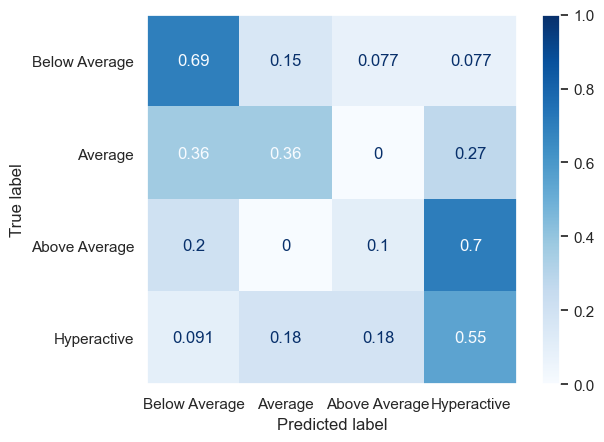

              precision    recall  f1-score   support

           0       0.56      0.69      0.62        13
           1       0.50      0.36      0.42        11
           2       0.25      0.10      0.14        10
           3       0.35      0.55      0.43        11

    accuracy                           0.44        45
   macro avg       0.42      0.43      0.40        45
weighted avg       0.43      0.44      0.42        45


--- DEC Summary ---
Accuracy: 44.4% | One Class Off: 33.3% | Skilled Frac: 64.4%
Total H-Skill: 0.0715 | Validation testH: 0.0536
Features: Index(['amm_OCT', 'amo_JUN', 'ao_OCT', 'epo_AUG', 'ngst_SEP', 'sgst_JUN',
       'mdrolr_NOV', 'mdrslp_OCT', 'pna_JUL', 'pna_OCT', 'tsa_JUL', 'whwp_JUL',
       'whwp_AUG', 'gomslp_SEP', 'gomslp_OCT', 'mdrt200_OCT', 'mdru850_AUG',
       'mdrv200_JUN', 'mdrv200_JUL', 'mdrv200_AUG', 'mdrv200_NOV',
       'mdrv850_JUL', 'mdrv850_AUG', 'mdrvws_JUN', 'gomu850_JUL',
       'nino34_forecast_JUN', 'nino34_forecast_JUL', 'nino34

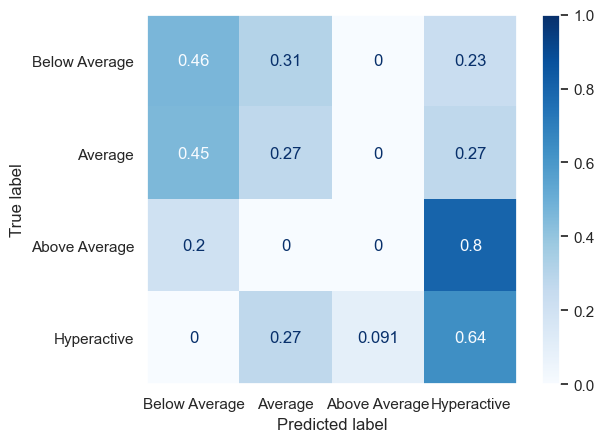

              precision    recall  f1-score   support

           0       0.46      0.46      0.46        13
           1       0.30      0.27      0.29        11
           2       0.00      0.00      0.00        10
           3       0.33      0.64      0.44        11

    accuracy                           0.36        45
   macro avg       0.27      0.34      0.30        45
weighted avg       0.29      0.36      0.31        45


--- JAN Summary ---
Accuracy: 35.6% | One Class Off: 40.0% | Skilled Frac: 57.8%
Total H-Skill: 0.0714 | Validation testH: 0.0531
Features: Index(['amm_OCT', 'ao_OCT', 'epo_AUG', 'ngst_SEP', 'mdrslp_OCT', 'pna_JUL',
       'pna_OCT', 'pna_DEC', 'whwp_JUL', 'whwp_AUG', 'whwp_DEC', 'gomslp_SEP',
       'gomslp_OCT', 'mdrt200_OCT', 'mdrv200_JUL', 'mdrv200_AUG',
       'mdrv200_NOV', 'mdrv850_AUG', 'gomu850_JUL', 'nino34_forecast_JUN',
       'nino34_forecast_JUL', 'nino34_forecast_AUG'],
      dtype='object')
Analyzing FEB...
Year   | Predicted    | Actual     

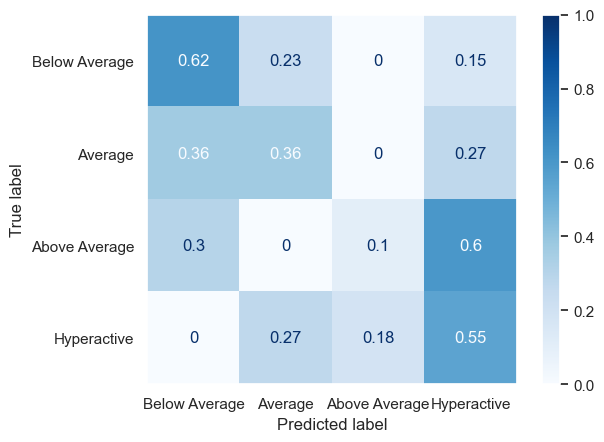

              precision    recall  f1-score   support

           0       0.53      0.62      0.57        13
           1       0.40      0.36      0.38        11
           2       0.33      0.10      0.15        10
           3       0.35      0.55      0.43        11

    accuracy                           0.42        45
   macro avg       0.40      0.41      0.38        45
weighted avg       0.41      0.42      0.40        45


--- FEB Summary ---
Accuracy: 42.2% | One Class Off: 33.3% | Skilled Frac: 57.8%
Total H-Skill: 0.0720 | Validation testH: 0.0346
Features: Index(['amm_OCT', 'ao_OCT', 'epo_AUG', 'ngst_SEP', 'mdrolr_NOV', 'mdrslp_JAN',
       'mdrslp_OCT', 'mdrsst_JAN', 'mdrsst_DEC', 'pna_OCT', 'pna_DEC',
       'tna_AUG', 'whwp_AUG', 'whwp_DEC', 'gomslp_SEP', 'gomslp_OCT',
       'mdrt200_OCT', 'mdru850_AUG', 'mdrv200_AUG', 'mdrv200_NOV',
       'mdrv850_AUG', 'nino34_forecast_JUN', 'nino34_forecast_JUL',
       'nino34_forecast_AUG'],
      dtype='object')
Analyzing MAR...

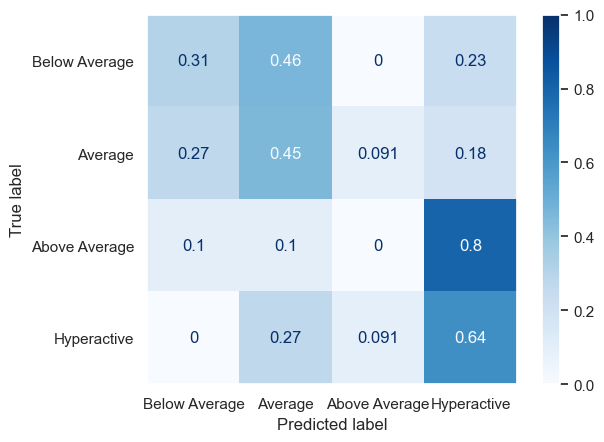

              precision    recall  f1-score   support

           0       0.50      0.31      0.38        13
           1       0.33      0.45      0.38        11
           2       0.00      0.00      0.00        10
           3       0.35      0.64      0.45        11

    accuracy                           0.36        45
   macro avg       0.30      0.35      0.30        45
weighted avg       0.31      0.36      0.31        45


--- MAR Summary ---
Accuracy: 35.6% | One Class Off: 44.4% | Skilled Frac: 57.8%
Total H-Skill: 0.0925 | Validation testH: 0.0879
Features: Index(['amm_OCT', 'amo_FEB', 'ao_OCT', 'ngst_FEB', 'ngst_SEP', 'mdrolr_NOV',
       'mdrslp_OCT', 'pna_OCT', 'whwp_DEC', 'gomslp_SEP', 'gomslp_OCT',
       'mdrt200_OCT', 'mdrv200_NOV', 'nino34_forecast_JUN',
       'nino34_forecast_AUG'],
      dtype='object')
Analyzing APR...
Year   | Predicted    | Actual       | Model Prob | Clim Prob  | Skill
----------------------------------------------------------------------
198

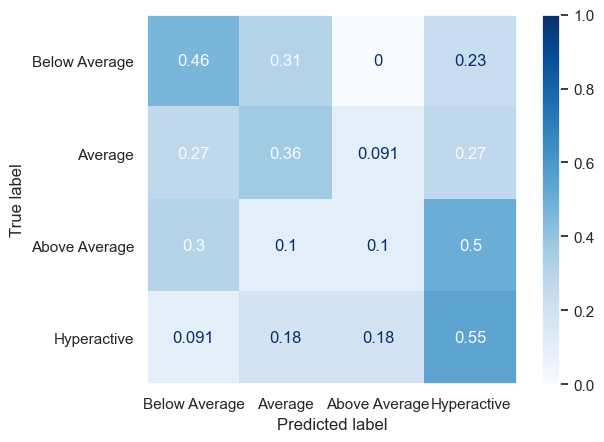

              precision    recall  f1-score   support

           0       0.46      0.46      0.46        13
           1       0.36      0.36      0.36        11
           2       0.25      0.10      0.14        10
           3       0.35      0.55      0.43        11

    accuracy                           0.38        45
   macro avg       0.36      0.37      0.35        45
weighted avg       0.36      0.38      0.36        45


--- APR Summary ---
Accuracy: 37.8% | One Class Off: 35.6% | Skilled Frac: 53.3%
Total H-Skill: 0.0605 | Validation testH: 0.0287
Features: Index(['amm_FEB', 'amm_OCT', 'amo_FEB', 'ao_OCT', 'ngst_FEB', 'mdrolr_NOV',
       'mdrslp_JAN', 'mdrslp_OCT', 'mdrsst_JAN', 'mdrsst_DEC', 'pna_OCT',
       'pna_DEC', 'whwp_DEC', 'gomslp_OCT', 'mdrt200_OCT', 'mdrv200_NOV',
       'nino34_forecast_JUN', 'nino34_forecast_JUL', 'nino34_forecast_AUG'],
      dtype='object')
Analyzing MAY...
Year   | Predicted    | Actual       | Model Prob | Clim Prob  | Skill
-------------

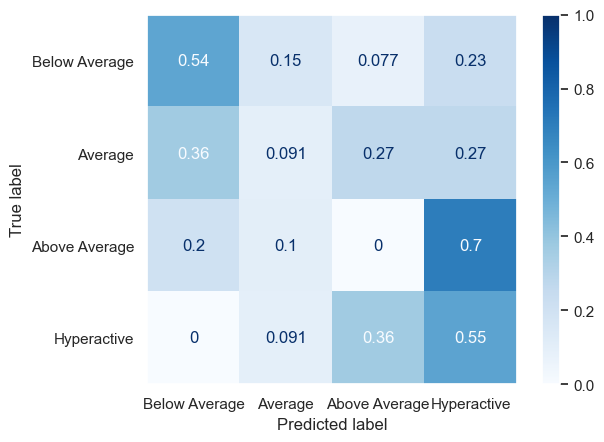

              precision    recall  f1-score   support

           0       0.54      0.54      0.54        13
           1       0.20      0.09      0.12        11
           2       0.00      0.00      0.00        10
           3       0.32      0.55      0.40        11

    accuracy                           0.31        45
   macro avg       0.26      0.29      0.27        45
weighted avg       0.28      0.31      0.28        45


--- MAY Summary ---
Accuracy: 31.1% | One Class Off: 46.7% | Skilled Frac: 57.8%
Total H-Skill: 0.0707 | Validation testH: 0.0352
Features: Index(['amm_FEB', 'amo_FEB', 'ngst_FEB', 'mdrolr_NOV', 'mdrslp_JAN', 'pna_DEC',
       'whwp_DEC', 'mdrv200_NOV', 'nino34_forecast_JUN'],
      dtype='object')
Analyzing JUN...
Year   | Predicted    | Actual       | Model Prob | Clim Prob  | Skill
----------------------------------------------------------------------
1981   | 2            | 1            |      23.3% |      40.0% |  -0.28
1982   | 1            | 0        

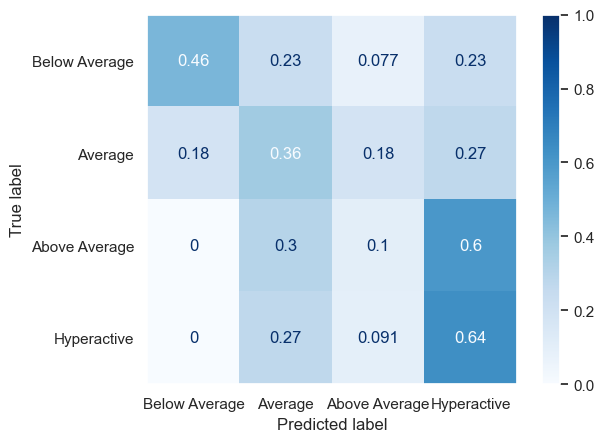

              precision    recall  f1-score   support

           0       0.75      0.46      0.57        13
           1       0.31      0.36      0.33        11
           2       0.20      0.10      0.13        10
           3       0.37      0.64      0.47        11

    accuracy                           0.40        45
   macro avg       0.41      0.39      0.38        45
weighted avg       0.43      0.40      0.39        45


--- JUN Summary ---
Accuracy: 40.0% | One Class Off: 37.8% | Skilled Frac: 57.8%
Total H-Skill: 0.0815 | Validation testH: 0.0478
Features: Index(['amm_FEB', 'amm_MAY', 'amo_FEB', 'amo_MAY', 'ngst_FEB', 'pna_DEC',
       'tna_MAY', 'whwp_DEC', 'roni_MAY', 'gomolr_MAY'],
      dtype='object')


In [320]:
hotneu=[]
coldneu=[]
trueneu=[]
for i in range(75):
    encount = sum(x > 0.5 for x in ronidat.iloc[i].values)
    lacount = sum(x < -0.5 for x in ronidat.iloc[i].values)

    borderencount = sum(x > 0.3 for x in ronidat.iloc[i].values)
    borderlacount = sum(x < -0.3 for x in ronidat.iloc[i].values)
    if (encount >= 3): #or (borderencount >= 3):
        hotneu.append(i)
    elif (lacount >= 3): #or (borderlacount >= 3):
        coldneu.append(i)
    else:
        trueneu.append(i)

allmonth=['DEC','JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV']
# ==========================================
# 5. Post-Processing & Importance Analysis
# ==========================================

# Main results container
analysis_results = {
    "months": [], 
    "test_skill": [], 
    "hard_test_skill": [], 
    "total_skill": [], 
    "train_skill": [], 
    "feature_count": []
}

# Yearly breakdown to identify "struggle years"
# Structure: { 'SEP': {1990: 0.5, 1991: -0.2...}, 'OCT': {...} }
yearly_diagnostic = {}
hardyearly_diagnostic = {}
yearly_raw_prob = {}
yearly_raw_clim = {}
yearly_raw_pred = {}
yearly_raw_corr = {}

# Importance storage
importance_data = {
    "train_rank": [], "train_vals": [],
    "test_rank": [], "test_vals": [],
    "all_rank": [], "all_vals": []
}

# Helper to convert year to index
def year_to_index(year, base_year=1951):
    return year - base_year

for i, month_key in enumerate(allmonth[:7]):
    # Load optimized data from your 'cpc' dictionary
    model_config = classset[i]
    best_features = model_config['features']
    best_params = model_config['params']
    
    print(f"Analyzing {month_key}...")

    # Tracking lists for this month
    likes, standard_clim, hard_clim = [], [], []
    imp_train, imp_test, imp_all = [], [], []
    
    # This will map the Year to the skill score (H) for that year
    month_yearly_h = {}
    hardmonth_yearly_h = {}
    month_yearly_raw_prob = {}
    month_yearly_raw_clim = {}
    month_yearly_raw_pred = {}
    month_yearly_raw_corr = {}
    correct_count = 0
    semicorrect_count = 0
    skill_count = 0
    print(f"{'Year':<6} | {'Predicted':<12} | {'Actual':<12} | {'Model Prob':<10} | {'Clim Prob':<10} | {'Skill'}")
    print("-" * 70)
    for test_idx in range(len(actualscore) - climperiod):
        year_val = test_idx + climperiod + 1951
        
        # 1. Setup Data Slices
        c_start, c_end = get_climatology_bounds(year_val, base_year=1951)
        start_idx, end_idx = year_to_index(c_start), year_to_index(c_end) + 1
        
        X_train, y_train = features[best_features].iloc[start_idx:end_idx], actualscore[start_idx:end_idx]
        X_test, y_test = features[best_features].iloc[[test_idx + climperiod]], actualscore[test_idx + climperiod]
        # Account for Class Weighing
        window_years = range(c_start, c_end + 1)
        target_weight_type = "neutral"
        if year_val in [yearzz[i] for i in hotneu]: target_weight_type = "el_nino"
        if year_val in [yearzz[i] for i in coldneu]: target_weight_type = "la_nina"
        dynamic_weights = []
        for yr in window_years:
            weight = 1.0
            if target_weight_type == "el_nino" and yr in [yearzz[i] for i in hotneu]:
                weight = 2.0
            elif target_weight_type == "la_nina" and yr in [yearzz[i] for i in coldneu]:
                weight = 2.0
            elif target_weight_type == "neutral" and yr in [yearzz[i] for i in trueneu]:
                weight = 1.0 # Optional: slight boost to other neutral years
            dynamic_weights.append(weight)
        
        sample_weights = np.array(dynamic_weights)

        # 2. Train and Predict
        rf = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42)
        rf.fit(X_train, y_train, sample_weight=sample_weights)

        raw_prob = rf.predict_proba(X_test)[0]
        y_pred = rf.predict(X_test)[0]
        y_prob = align_class_probabilities(raw_prob, rf.classes_, typecast)
        likescore = y_prob[y_test]
        
        # 3. Climatology Baseline
        clim_prob = np.bincount(y_train, minlength=len(typecast)) / len(y_train)
        test_clim = clim_prob[y_test]

        # 4. Yearly Residual Calculation
        if test_clim != 1: # Avoid division by zero
            h_yearly = (likescore - test_clim) / (1 - test_clim)
        else:
            h_yearly = 0
            
        month_yearly_h[year_val] = h_yearly
        month_yearly_raw_prob[year_val] = likescore
        month_yearly_raw_clim[year_val] = test_clim
        month_yearly_raw_pred[year_val] = y_pred
        month_yearly_raw_corr[year_val] = y_test
        is_correct = np.argmax(y_prob) == y_test
        is_semicorrect = (abs(np.argmax(y_prob) - 1) == y_test) or (abs(np.argmax(y_prob) + 1) == y_test)
        if is_correct: correct_count += 1
        if is_semicorrect: semicorrect_count += 1
        if h_yearly > 0: skill_count += 1

        if is_correct:
            color_match = Fore.GREEN
        elif is_semicorrect:
            color_match = Fore.YELLOW
        else:
            color_match = Fore.RED

        color_skill = Fore.GREEN if h_yearly > 0 else (Fore.RED if h_yearly < 0 else Fore.WHITE)
        if target_weight_type == 'el_nino':
            color_weight = Fore.RED
        elif target_weight_type == 'la_nina':
            color_weight = Fore.BLUE
        else:
            color_weight = Fore.WHITE
            

        print(f"{color_weight}{year_val:<6}{Style.RESET_ALL} | {color_match}{typecast[y_pred]:<12}{Style.RESET_ALL} | {typecast[y_test]:<12} |"
              f"{likescore:11.1%} | {test_clim:10.1%} | {color_skill}{h_yearly:>+6.2f}{Style.RESET_ALL}")

        # 5. Store for Aggregate Likelihoods
        if test_clim != 0:
            likes.append(likescore)
            standard_clim.append(test_clim)

        # Hard Test Logic
        if test_idx >= 35:
            raw_pred = rf.predict(X_test)[0]
            y_short = actualscore[(test_idx + climperiod - 15) : test_idx + climperiod]
            hard_clim_prob = np.bincount(y_short, minlength=len(typecast)) / len(y_short)
            hard_test_clim = hard_clim_prob[y_test]
            hardh_yearly = (likescore - hard_test_clim) / (1 - hard_test_clim)
            hardmonth_yearly_h[year_val] = hardh_yearly
            hard_clim.append(hard_test_clim)



        # Feature Importance
        importance = rf.feature_importances_
        imp_all.append(importance)
        if test_idx < 35: imp_train.append(importance)
        else: imp_test.append(importance)

    # ==========================================
    # Aggregation & Ranking
    # ==========================================
    
    # Calculate Likelihoods (Geometric Means)
    train_h = (calculate_likelihood(likes[:35]) - calculate_likelihood(standard_clim[:35])) / (1 - calculate_likelihood(standard_clim[:35]))
    test_h = (calculate_likelihood(likes[35:]) - calculate_likelihood(standard_clim[35:])) / (1 - calculate_likelihood(standard_clim[35:]))
    hard_h = (calculate_likelihood(likes[35:]) - calculate_likelihood(hard_clim)) / (1 - calculate_likelihood(hard_clim))
    total_h = (calculate_likelihood(likes) - calculate_likelihood(standard_clim)) / (1 - calculate_likelihood(standard_clim))
    
    cm = confusion_matrix([*month_yearly_raw_corr.values()], [*month_yearly_raw_pred.values()], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=type_labels)
    disp.plot(cmap=plt.cm.Blues,im_kw={'vmin': 0, 'vmax': 1})
    plt.grid(False)
    plt.show()
    print(classification_report([*month_yearly_raw_corr.values()], [*month_yearly_raw_pred.values()]))
    frac_corr = correct_count / 45
    frac_skill = skill_count / 45
    frac_semi_corr = semicorrect_count / 45

    frac_realcorr=(correct_count+(0.5*semicorrect_count)) / 45
    print(f"\n{Style.BRIGHT}--- {month_key} Summary ---{Style.RESET_ALL}")
    print(f"Accuracy: {frac_corr:.1%} | One Class Off: {frac_semi_corr:.1%} | Skilled Frac: {frac_skill:.1%}")
    print(f"Total H-Skill: {total_h:.4f} | Validation testH: {test_h:.4f}")
    print(f"Features: {features[best_features].columns}")

    # Helper for feature ranking
    def get_rank(imp_list, names):
        means = np.mean(imp_list, axis=0)
        idx = np.argsort(means)[::-1]
        return [names[j] for j in idx], means[idx].tolist()

    train_names, train_vals = get_rank(imp_train, best_features)
    test_names, test_vals = get_rank(imp_test, best_features)
    all_names, all_vals = get_rank(imp_all, best_features)

    # Final Save
    analysis_results["months"].append(month_key)
    analysis_results["test_skill"].append(test_h)
    analysis_results["train_skill"].append(train_h)
    analysis_results["hard_test_skill"].append(hard_h)
    analysis_results["total_skill"].append(total_h)
    
    yearly_diagnostic[month_key] = month_yearly_h
    hardyearly_diagnostic[month_key] = hardmonth_yearly_h
    yearly_raw_prob[month_key] = month_yearly_raw_prob
    yearly_raw_clim[month_key] = month_yearly_raw_clim
    yearly_raw_pred[month_key] = month_yearly_raw_pred
    yearly_raw_corr[month_key] = month_yearly_raw_corr
    
    importance_data["train_rank"].append(train_names)
    importance_data["train_vals"].append(train_vals)
    importance_data["test_rank"].append(test_names)
    importance_data["test_vals"].append(test_vals)
    importance_data["all_rank"].append(all_names)
    importance_data["all_vals"].append(all_vals)    

In [321]:
inseason=['JUN','JUL','AUG','SEP','OCT','NOV']
neomonth=['DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']
ronidat=pure_data['roni'][inseason].iloc[1:]
bigen=[]
bigla=[]
hotneu=[]
coldneu=[]
trueneu=[]
ensodata = {}

recentyearzz=yearzz[30:]
for i in range(45):
    encount = sum(x > 0.5 for x in ronidat.iloc[30:].iloc[i].values)
    lacount = sum(x < -0.5 for x in ronidat.iloc[30:].iloc[i].values)

    borderencount = sum(x > 0.3 for x in ronidat.iloc[30:].iloc[i].values)
    borderlacount = sum(x < -0.3 for x in ronidat.iloc[30:].iloc[i].values)
    if (encount >= 3): #or (borderencount >= 3):
        hotneu.append(i)
    elif (lacount >= 3): #or (borderlacount >= 3):
        coldneu.append(i)
    else:
        trueneu.append(i)

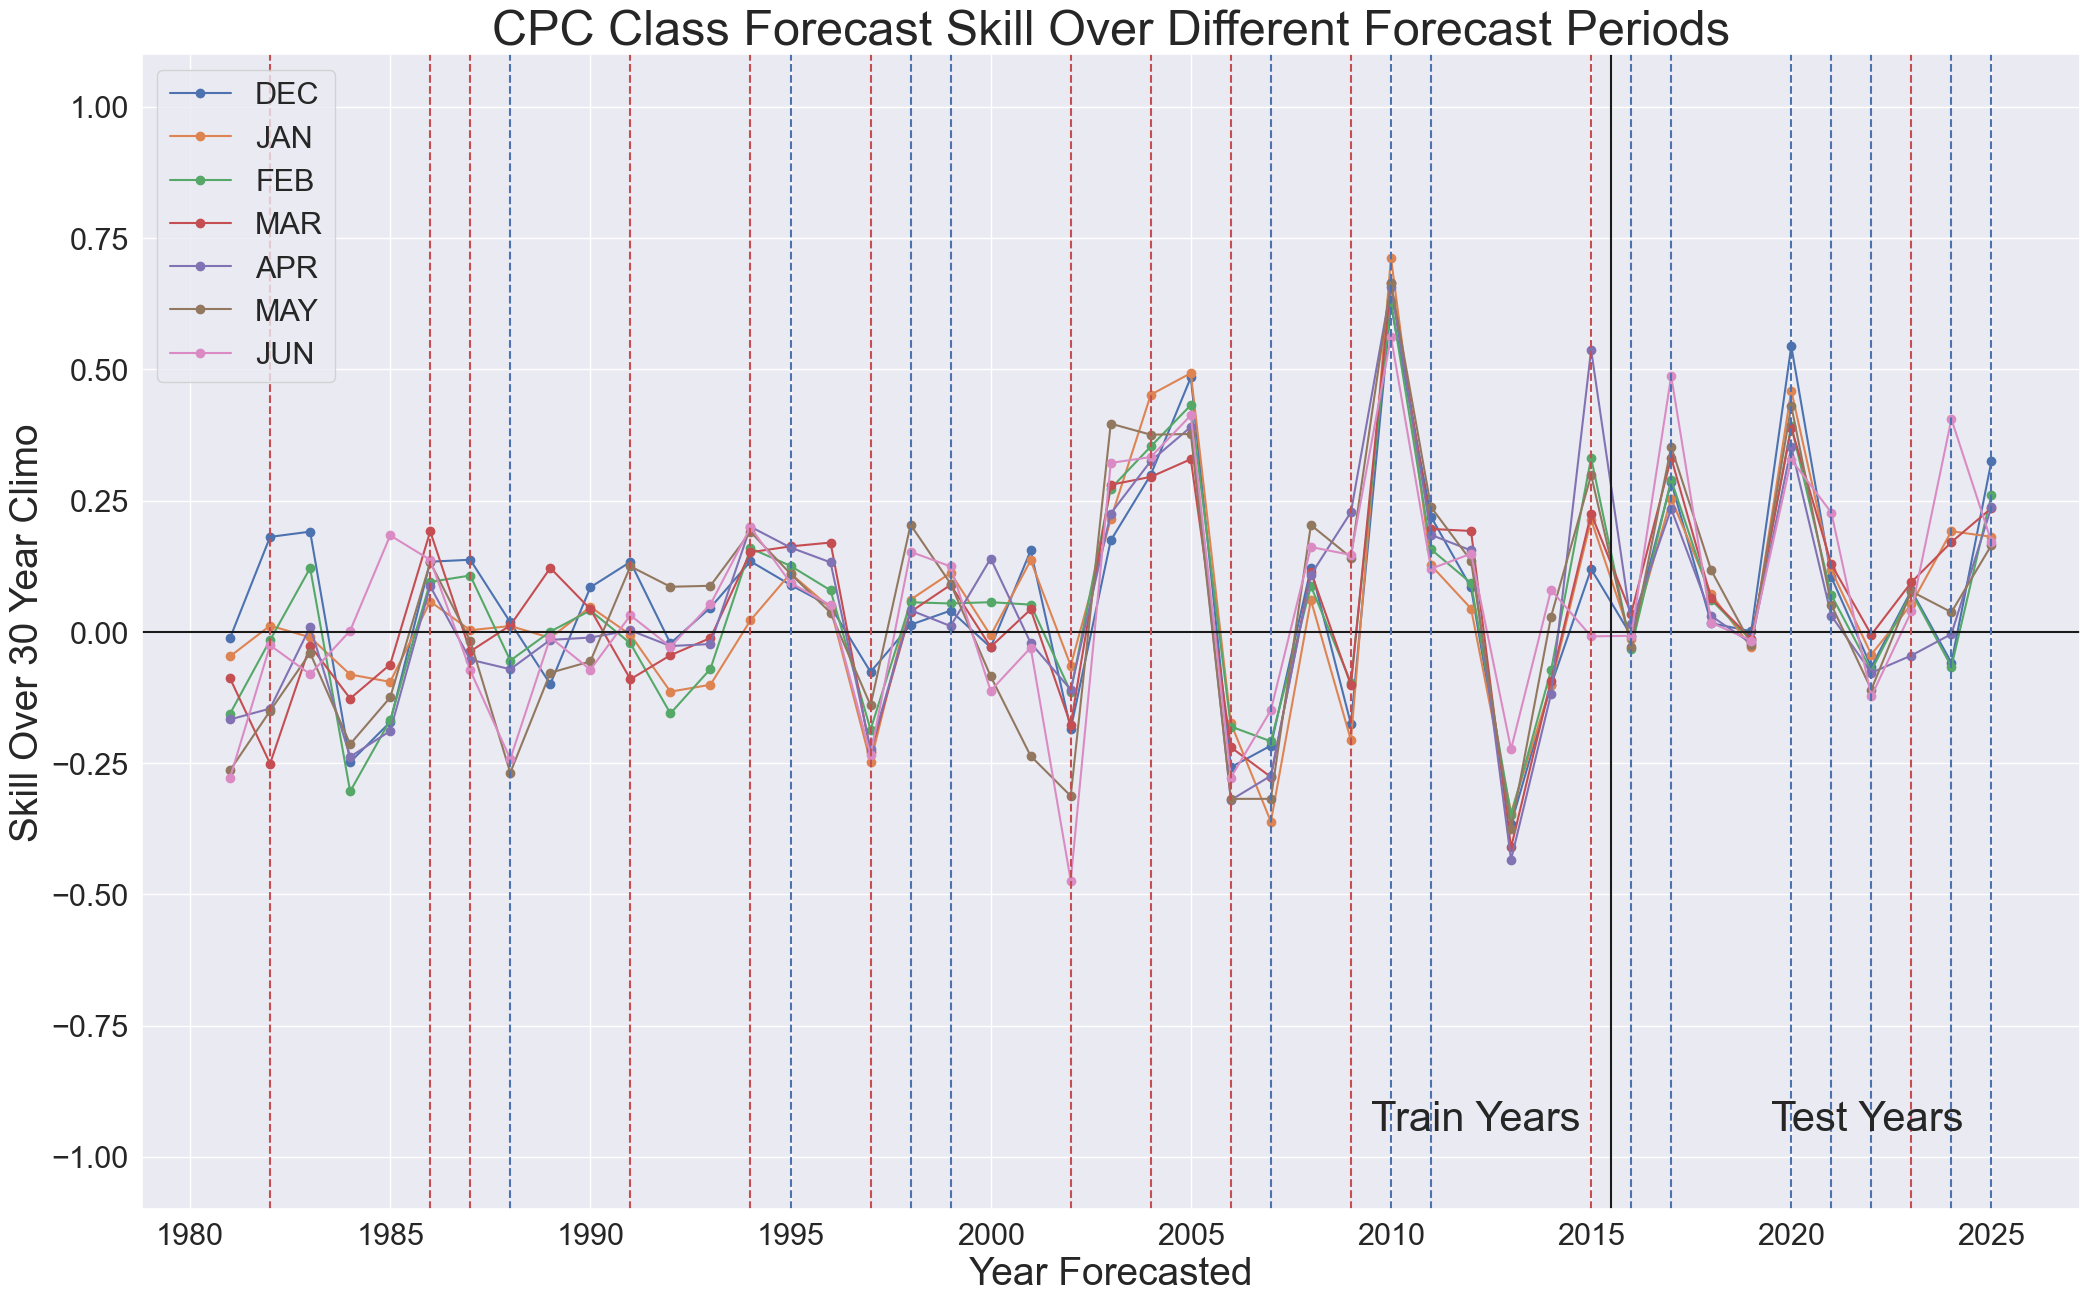

In [322]:
# ==========================================
# Plotting Individual Year Skills Relative to Forecast Month
# ==========================================
plt.figure(figsize=(25,15))
for i in (allmonth[:7]):
    # Plot each individual H-score skill for each month forecast
    plt.plot(yearzz[climperiod:],[*yearly_diagnostic[i].values()],'-o',label='{}'.format(i))
plt.axhline(y=0,color='k')
plt.axvline(x=2015.5,color='k')
# Set y lim values
plt.ylim(-1.1,1.1)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)
# Mark what years are test years
plt.text(x=2019.5,y=-.95,s='Test Years',fontsize=30)
# Mark what years are train years
plt.text(x=2009.5,y=-.95,s='Train Years',fontsize=30)
plt.xticks(np.arange(1980, 2026, 5))
plt.xlabel('Year Forecasted',fontsize=28)
plt.ylabel('Skill Over 30 Year Climo',fontsize=28)
plt.legend(fontsize=22)
for i in range(45):
    if i in hotneu:
        plt.axvline(x=1981+i,color='r',linestyle='--')
    elif i in coldneu:
        plt.axvline(x=1981+i,color='b',linestyle='--')
plt.title(f'{class_type} Class Forecast Skill Over Different Forecast Periods',fontsize=35)
plt.show()

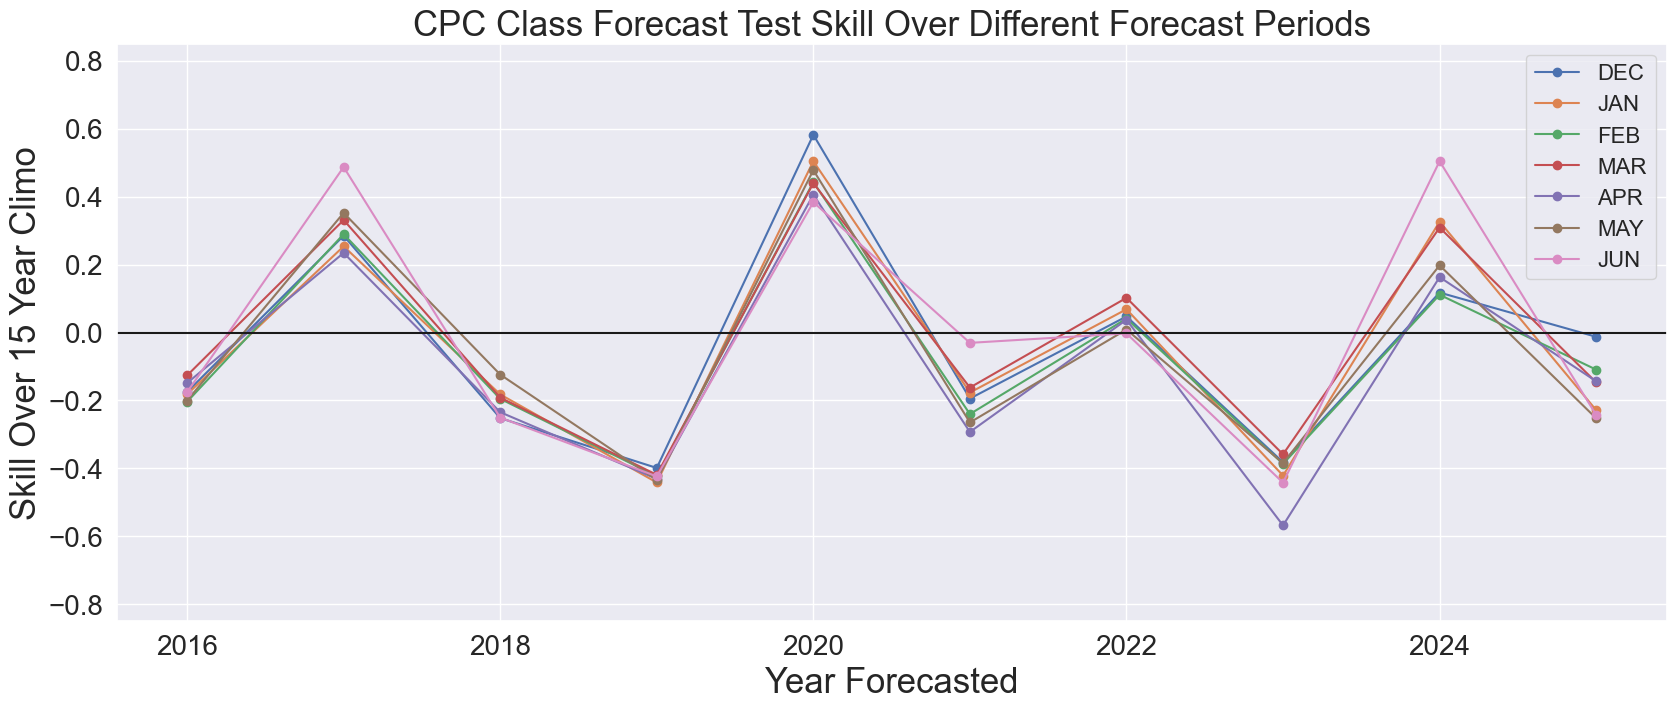

In [323]:
# ==========================================
# Plotting Individual Test Year Harder Climatology Skills Relative to Forecast Month
# ==========================================
plt.figure(figsize=(20,7.5))

for i in (allmonth[:7]):
    # Plot each individual H-score skill for each month forecast
    plt.plot(yearzz[climperiod+35:],[*hardyearly_diagnostic[i].values()],'-o',label='{}'.format(i))
plt.axhline(y=0,color='k')
plt.ylim(-.85,.85)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.xlabel('Year Forecasted',fontsize=25)
plt.ylabel('Skill Over 15 Year Climo',fontsize=25)
plt.legend(fontsize=16)
plt.title(f'{class_type} Class Forecast Test Skill Over Different Forecast Periods',fontsize=25)
plt.show()

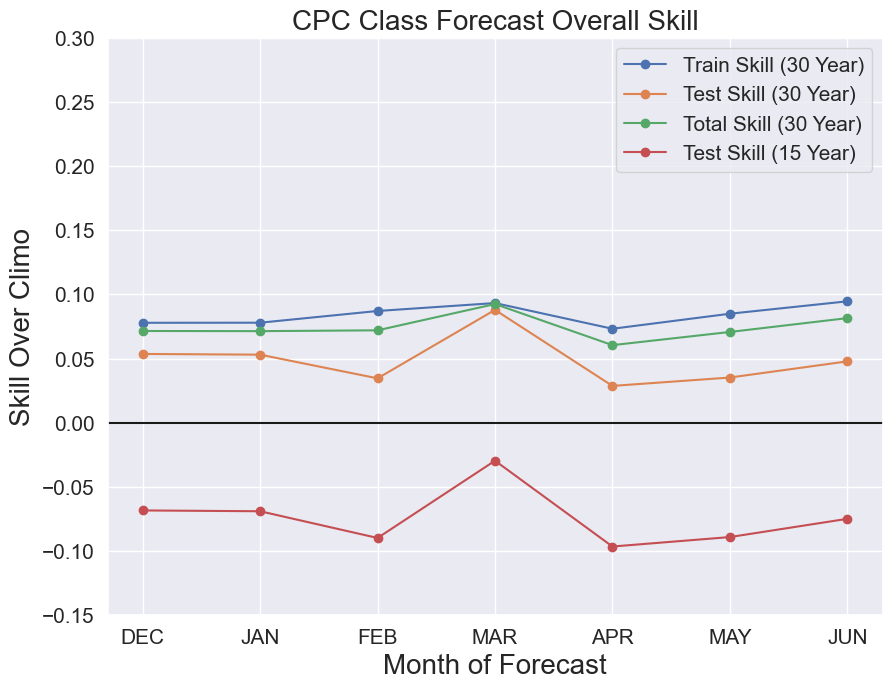

In [319]:
# ==========================================
# Plotting Total Skill Relative to Forecast Month
# ==========================================
plt.figure(figsize=(10,7.5))
# H-Skill Scores
plt.plot(range(7),analysis_results["train_skill"],'-o',label='Train Skill (30 Year)')
plt.plot(range(7),analysis_results["test_skill"],'-o',label='Test Skill (30 Year)')
plt.plot(range(7),analysis_results["total_skill"],'-o',label='Total Skill (30 Year)')
plt.plot(range(7),analysis_results["hard_test_skill"],'-o',label='Test Skill (15 Year)', color='C3')
# Modify Ticks
plt.xticks(range(7),labels=allmonth[:7],fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=15)
plt.xlabel('Month of Forecast',fontsize=20)
plt.ylabel('Skill Over Climo',fontsize=20)
plt.axhline(y=0,color='k')
plt.ylim(-.15,.3)
plt.title(f'{class_type} Class Forecast Overall Skill',fontsize=20)
plt.show()

In [295]:
lookfor=['El Nino', 'La Nina', 'Neutral']
lookval=[hotneu,coldneu,trueneu]
for i,j in enumerate(lookval):
    print(lookfor[i])
    for k in neomonth:
        raw_prob = np.asarray([*yearly_raw_prob[k].values()])[j]
        raw_clim = np.asarray([*yearly_raw_clim[k].values()])[j]
        total_h = (calculate_likelihood(raw_prob) - calculate_likelihood(raw_clim)) / (1 - calculate_likelihood(raw_clim))
        print(k,np.round(total_h,4))

El Nino
DEC 0.0608
JAN 0.0361
FEB 0.0639
MAR 0.0069
APR 0.0245
MAY 0.038
JUN -0.0109
La Nina
DEC 0.0988
JAN 0.1146
FEB 0.095
MAR 0.1425
APR 0.0922
MAY 0.1061
JUN 0.1272
Neutral
DEC 0.0404
JAN 0.0353
FEB 0.0437
MAR 0.0691
APR 0.0345
MAY 0.0402
JUN 0.0644


# Check Feature Importances

In [324]:
feature_names = ['amm', 'amo', 'ao', 'censo', 'dm', 'epo', 'ggst', 'ngst', 'sgst',
    'mdrolr', 'mdrslp', 'mdrsst', 'nao', 'pdo', 'pna', 'qbo', 'sfi', 'soi', 'tni', 
    'tna', 'tsa', 'whwp', 'wpi', 'nino12', 'nino3', 'nino34', 'nino4', 'mei', 'roni', 
    'sahel', 'mdru200', 'mdru850', 'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'mdrt200', 'gomolr', 'gomslp', 'rhsal', 'nino34_forecast'
]

atlnames=['amm', 'amo', 'ao', 'dm', 'mdrolr', 
    'mdrslp', 'mdrsst', 'gomolr', 'gomslp', 'rhsal', 
    'nao', 'sfi', 'tna', 'tsa', 'sahel'
]
pacnames=['censo', 'epo', 'pdo', 'pna',  
    'soi', 'tni', 'wpi', 'nino12', 
    'nino3', 'nino34', 'nino4', 'mei', 'roni', 'nino34_forecast'
]
jointnames=['mdru200', 'mdru850',
    'mdrv200', 'mdrv850', 'mdrvws', 'gomu200', 'gomu850',
    'gomv200', 'gomv850', 'gomvws', 'whwp', 'mdrt200'
           ]
      
    
globalnames=['ggst', 'ngst', 'sgst', 'qbo']

ssttype=['amm','amo','censo','dm','ggst','ngst','sgst','mdrsst','pdo','tni','tna','tsa','whwp','nino12','nino3','nino34','nino4','mei','roni', 'nino34_forecast']
prestype=['ao','epo','mdrslp','nao','pna','soi','wpi','gomslp']
windtype=['mdru200', 'mdru850','mdrv200', 'mdrv850', 'mdrvws','qbo','gomu200','gomu850','gomv200','gomv850','gomvws']
othertype=['sfi','mdrolr','sahel','mdrt200','rhsal','gomolr']
allmonth=['DEC','JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV']

typemode=[ssttype,prestype,windtype,othertype]
regionmode=[atlnames,pacnames,jointnames,globalnames]
regionnames=["Atlantic","Pacific","Joint Feat","Global"]
typenames=['SST','Pressure','Wind','Other']
neomonth=['DEC', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN']

In [327]:
def plot_feature_distribution(month_idx, importance_data, class_type):
    """
    Creates a stacked bar chart showing feature importance distribution 
    by both Region (X-axis) and Variable Type (Stacks).
    """
    # 1. Configuration: Mapping features to Categories
    region_map = {name: "Atlantic" for name in atlnames}
    region_map.update({name: "Pacific" for name in pacnames})
    region_map.update({name: "Joint Feat" for name in jointnames})
    region_map.update({name: "Global" for name in globalnames})

    type_map = {name: "SST" for name in ssttype}
    type_map.update({name: "Pressure" for name in prestype})
    type_map.update({name: "Wind" for name in windtype})
    type_map.update({name: "Other" for name in othertype})

    # 2. Data Extraction
    touse = importance_data["test_rank"][month_idx]
    print(touse)
    vals = importance_data["test_vals"][month_idx]
    month_name = neomonth[month_idx]
    length=len(touse)
    
    # Initialize a structured dictionary to hold sums: {Region: {Type: value}}
    regions = ["Atlantic", "Pacific", "Joint Feat", "Global"]
    v_types = ["SST", "Pressure", "Wind", "Other"]
    
    data = {r: {t: 0.0 for t in v_types} for r in regions}

    # 3. Aggregate Data
    for feature_full, weight in zip(touse, vals):
        # Strip the month suffix (e.g., 'nino34_AUG' -> 'nino34')
        base_name = feature_full.split('_')[0]
        
        region = region_map.get(base_name)
        v_type = type_map.get(base_name)
        
        if region and v_type:
            data[region][v_type] += weight

    # 4. Prepare for Plotting
    # We want a 2D array where rows = types and columns = regions
    plot_matrix = np.array([[data[r][t] for r in regions] for t in v_types])
    
    # 5. Visualization
    fig, ax = plt.subplots(figsize=(14, 9), facecolor='white')
    colors = ['C0', 'C1', 'C2', 'C3'] # Professional palette
    bottom = np.zeros(len(regions))

    for i, t_name in enumerate(v_types):
        row = plot_matrix[i]
        total_type_pct = np.sum(row) * 100
        
        bars = ax.bar(regions, row, bottom=bottom, color=colors[i], 
                      label=f'{t_name}: {total_type_pct:.1f}%')

        # Add centered text labels
        for bar in bars:
            h = bar.get_height()
            if h > 0: 
                if i==1:
                    # For Orange Bars to Make it Easier to Read
                    txt_color = 'black'
                else:
                    txt_color = 'white'
                ax.text(bar.get_x() + bar.get_width()/2, 
                        bar.get_y() + h/2, 
                        f'{h*100:.1f}%', 
                        ha='center', va='center', 
                        color=txt_color, fontweight='bold', fontsize=12)
        bottom += row

    # 6. Final Formatting
    ax.set_ylabel("Contribution to Model Importance (Sum)", fontsize=20)
    ax.set_title(f'{class_type} Model Feature Distribution: {month_name} Forecast ({length} Features)', fontsize=22, pad=20)
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.linspace(0, 1, 11))
    ax.set_yticklabels([f'{x}%' for x in range(0, 101, 10)])
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=15)
    
    ax.legend(fontsize=15, title="Variable Types", title_fontsize=20, loc='upper left', bbox_to_anchor=(1, 1))

    
    plt.tight_layout()
    return fig

0
['mdrvws_JUN', 'nino34_forecast_AUG', 'nino34_forecast_JUL', 'mdrv200_JUN', 'mdrt200_OCT', 'nino34_forecast_JUN', 'mdrv850_AUG', 'pna_JUL', 'gomu850_JUL', 'mdru850_AUG', 'mdrolr_NOV', 'mdrslp_OCT', 'pna_OCT', 'whwp_JUL', 'sgst_JUN', 'mdrv850_JUL', 'gomslp_OCT', 'ngst_SEP', 'whwp_AUG', 'mdrv200_NOV', 'ao_OCT', 'mdrv200_AUG', 'epo_AUG', 'gomslp_SEP', 'tsa_JUL', 'amm_OCT', 'amo_JUN', 'mdrv200_JUL']
1
['nino34_forecast_AUG', 'pna_JUL', 'nino34_forecast_JUN', 'whwp_DEC', 'mdrv200_NOV', 'nino34_forecast_JUL', 'whwp_JUL', 'gomu850_JUL', 'mdrv200_AUG', 'mdrslp_OCT', 'mdrt200_OCT', 'pna_DEC', 'ao_OCT', 'mdrv850_AUG', 'gomslp_OCT', 'whwp_AUG', 'ngst_SEP', 'epo_AUG', 'gomslp_SEP', 'amm_OCT', 'pna_OCT', 'mdrv200_JUL']
2
['nino34_forecast_JUN', 'mdrv850_AUG', 'mdrv200_NOV', 'nino34_forecast_AUG', 'whwp_DEC', 'mdru850_AUG', 'mdrolr_NOV', 'mdrv200_AUG', 'mdrt200_OCT', 'pna_DEC', 'mdrsst_JAN', 'gomslp_OCT', 'mdrslp_OCT', 'nino34_forecast_JUL', 'whwp_AUG', 'ao_OCT', 'mdrsst_DEC', 'mdrslp_JAN', 'pna_O

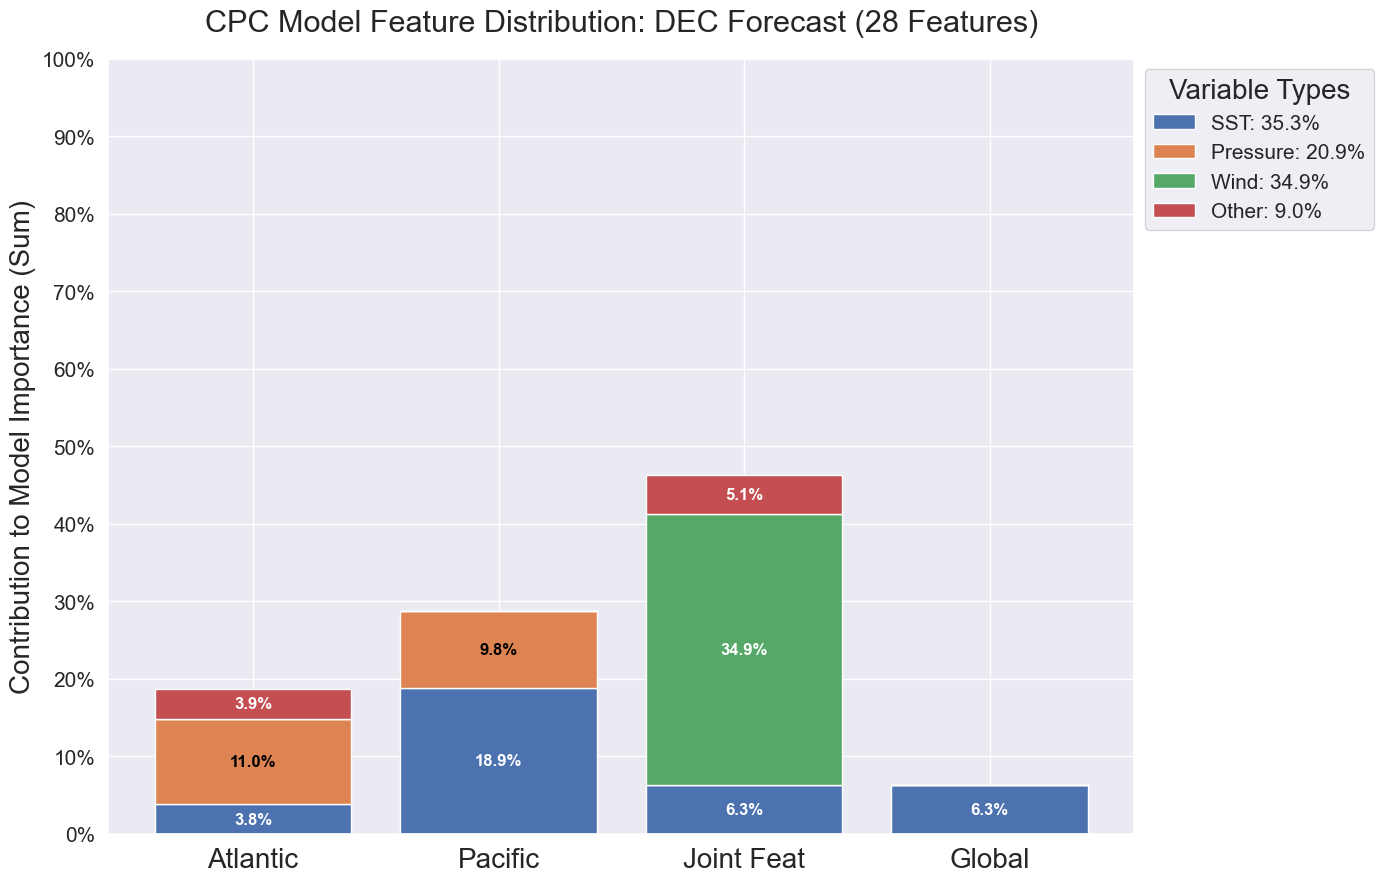

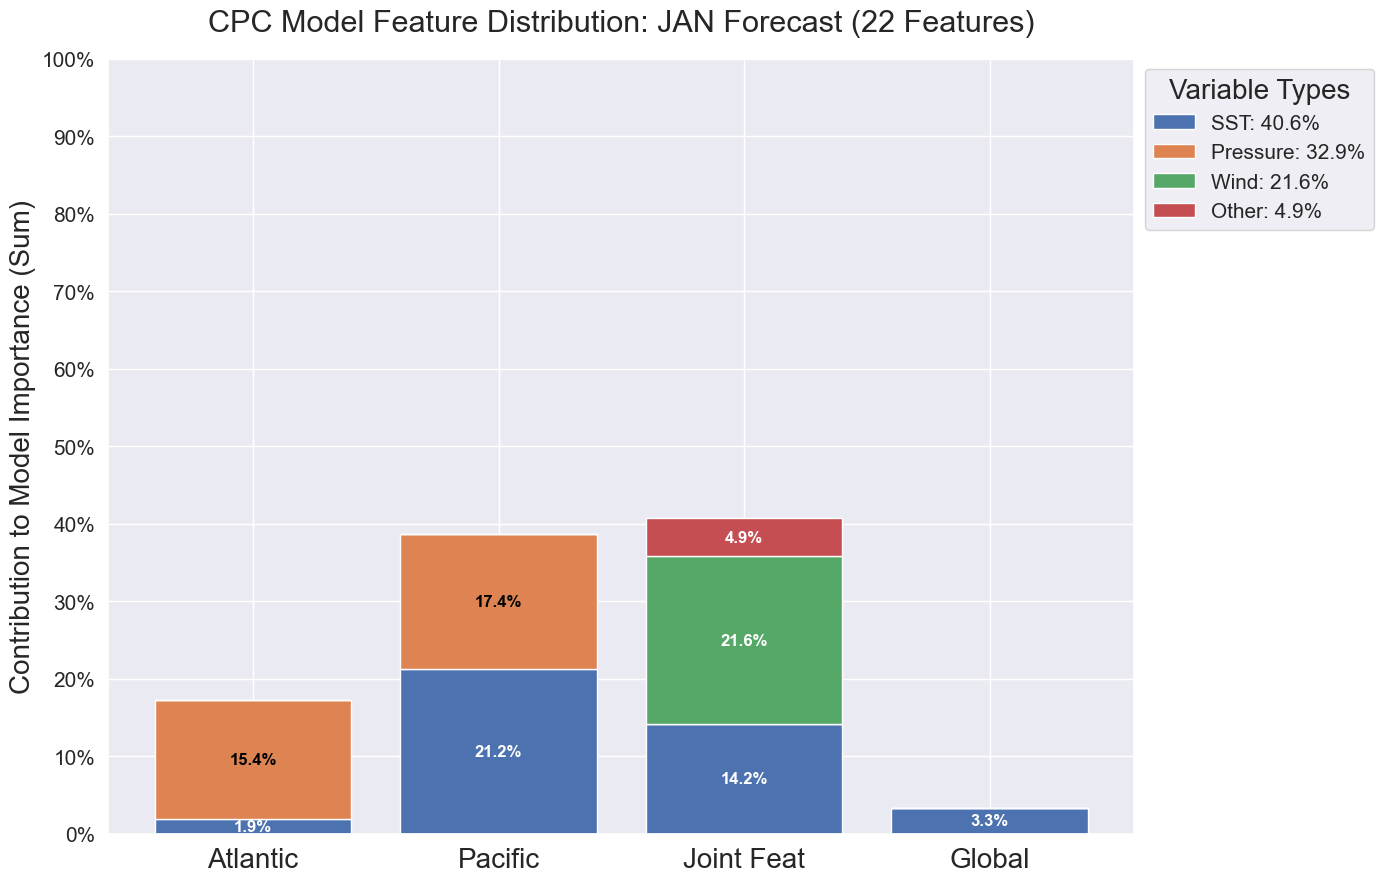

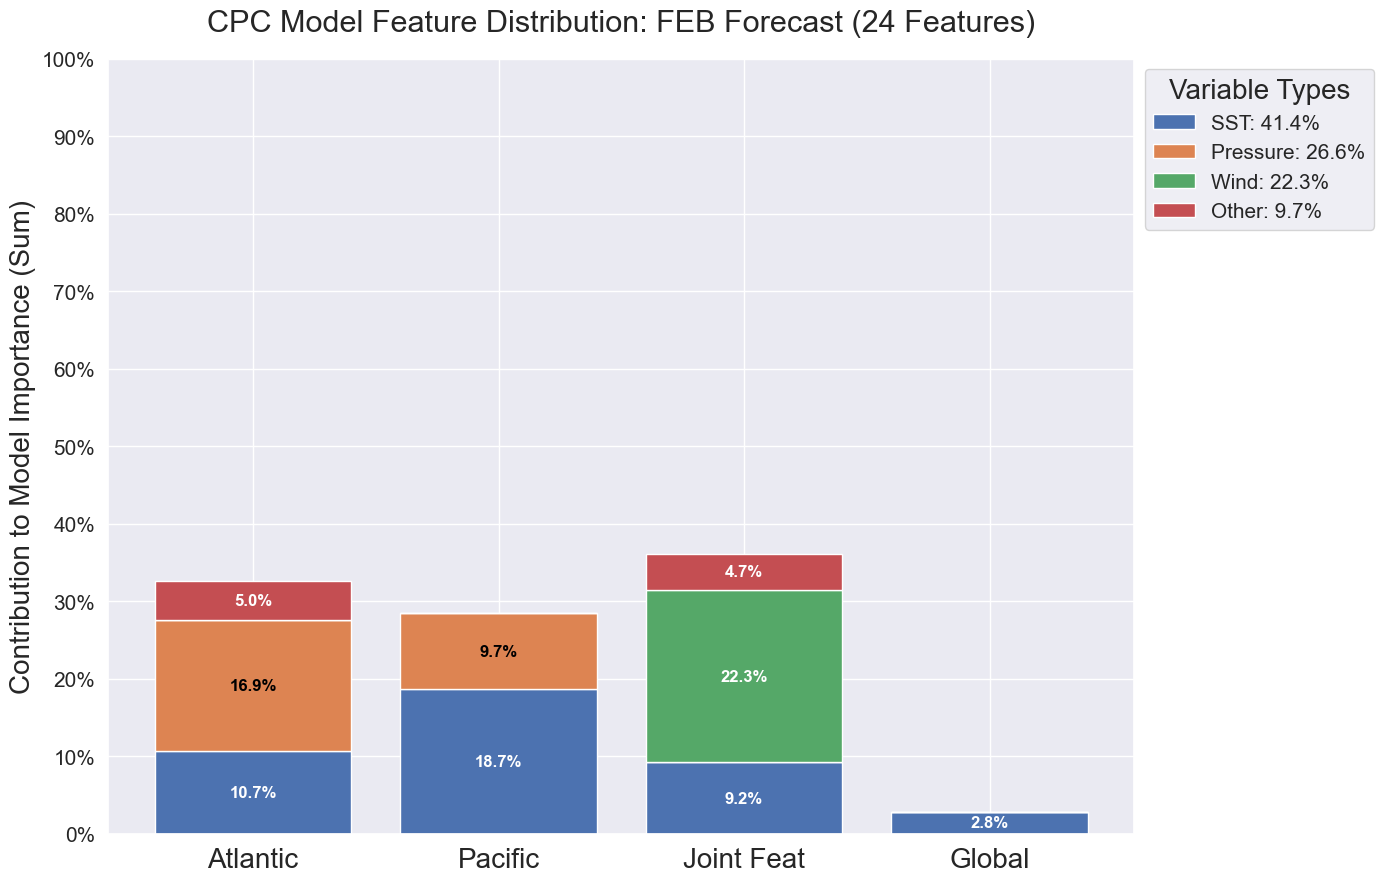

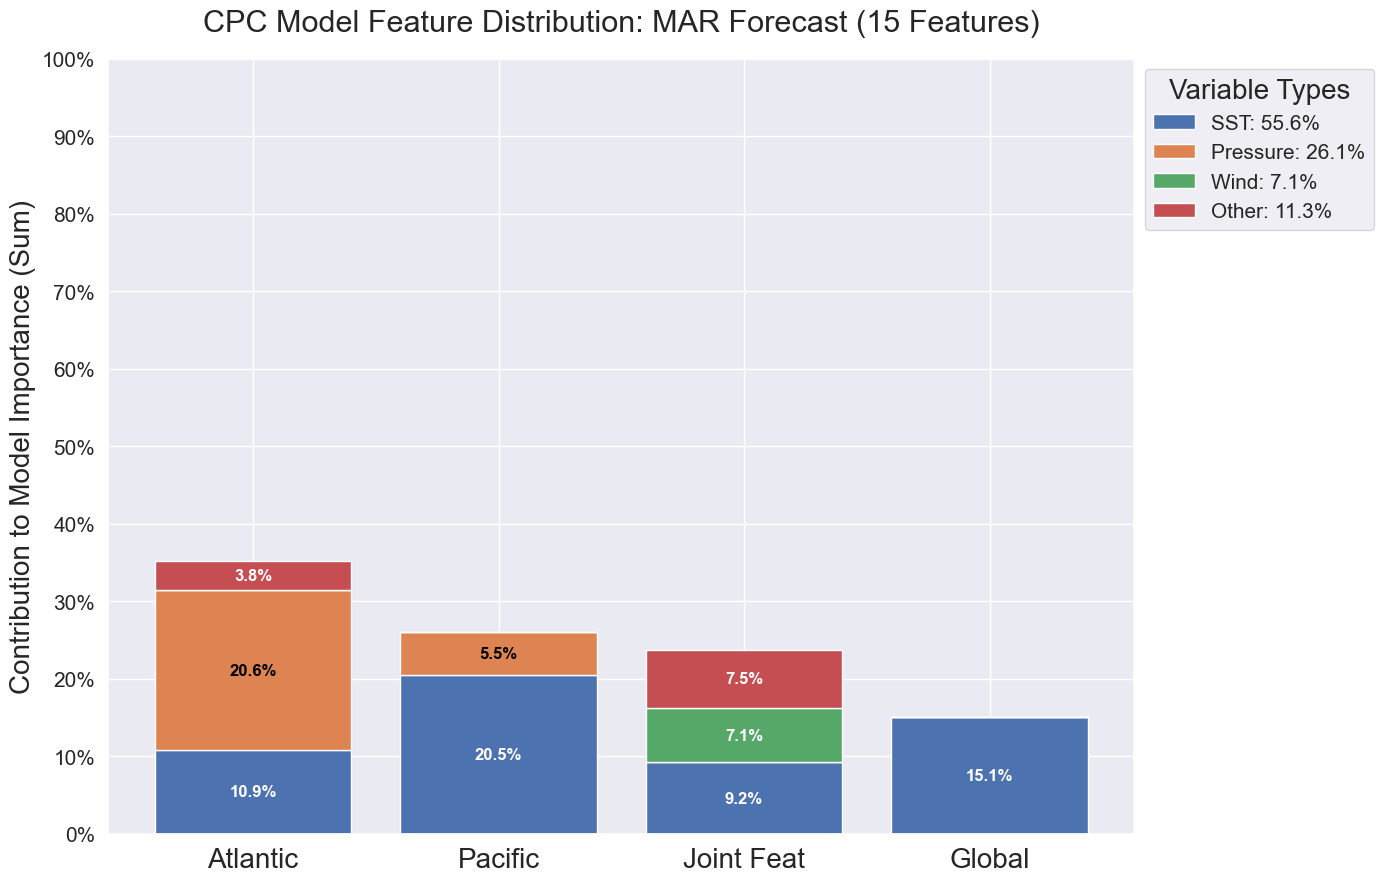

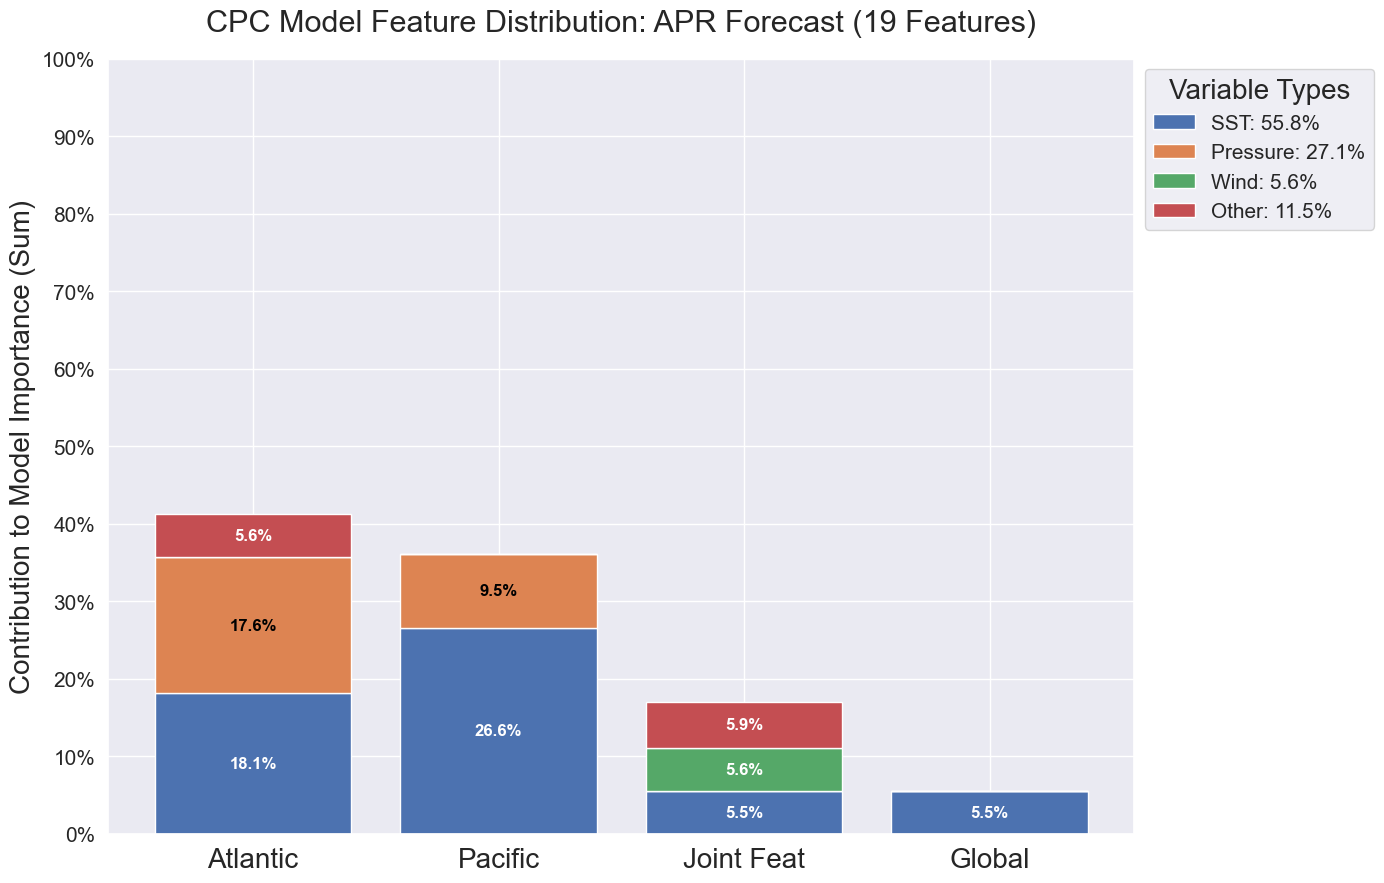

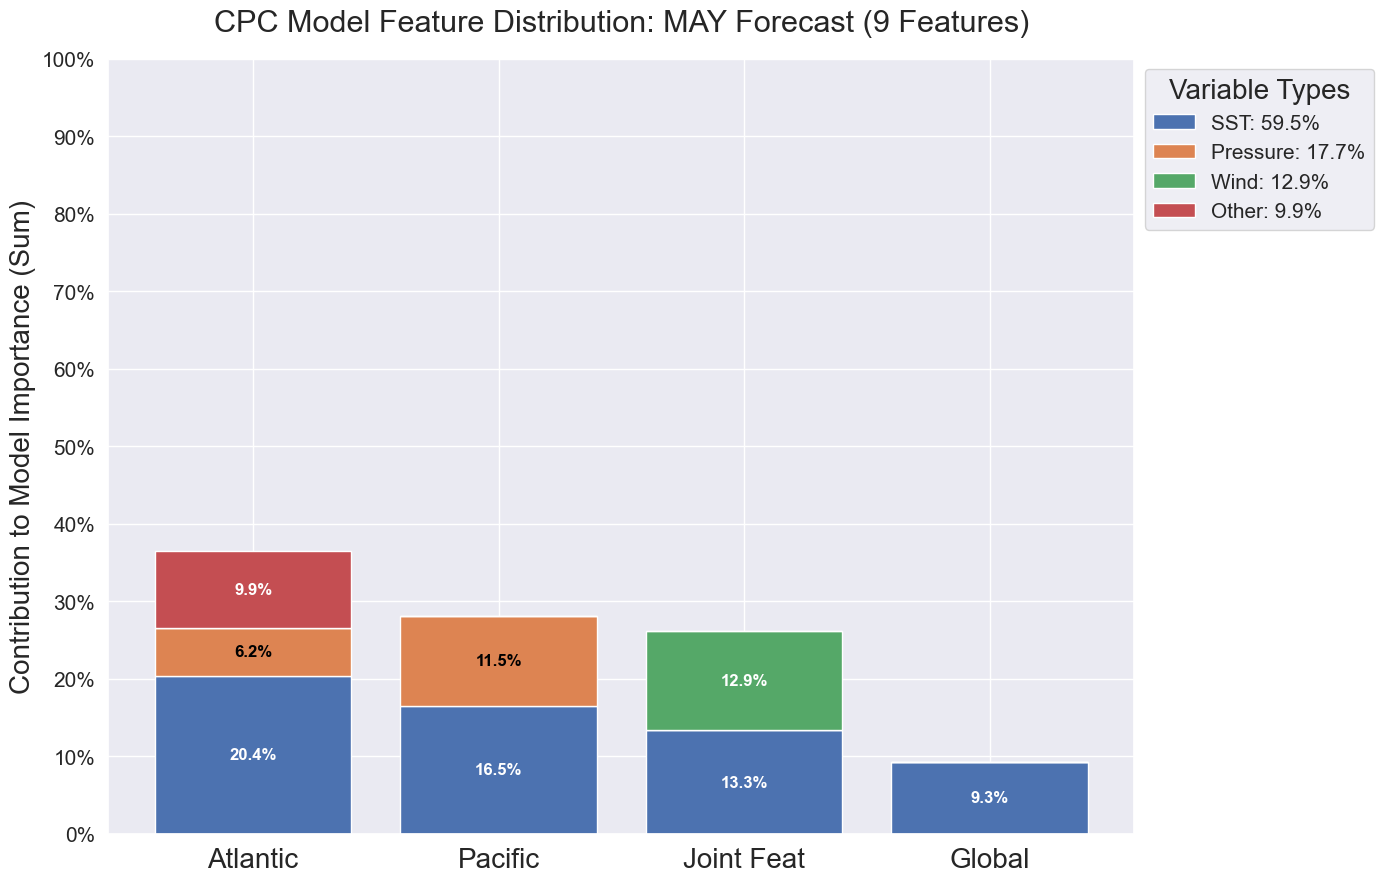

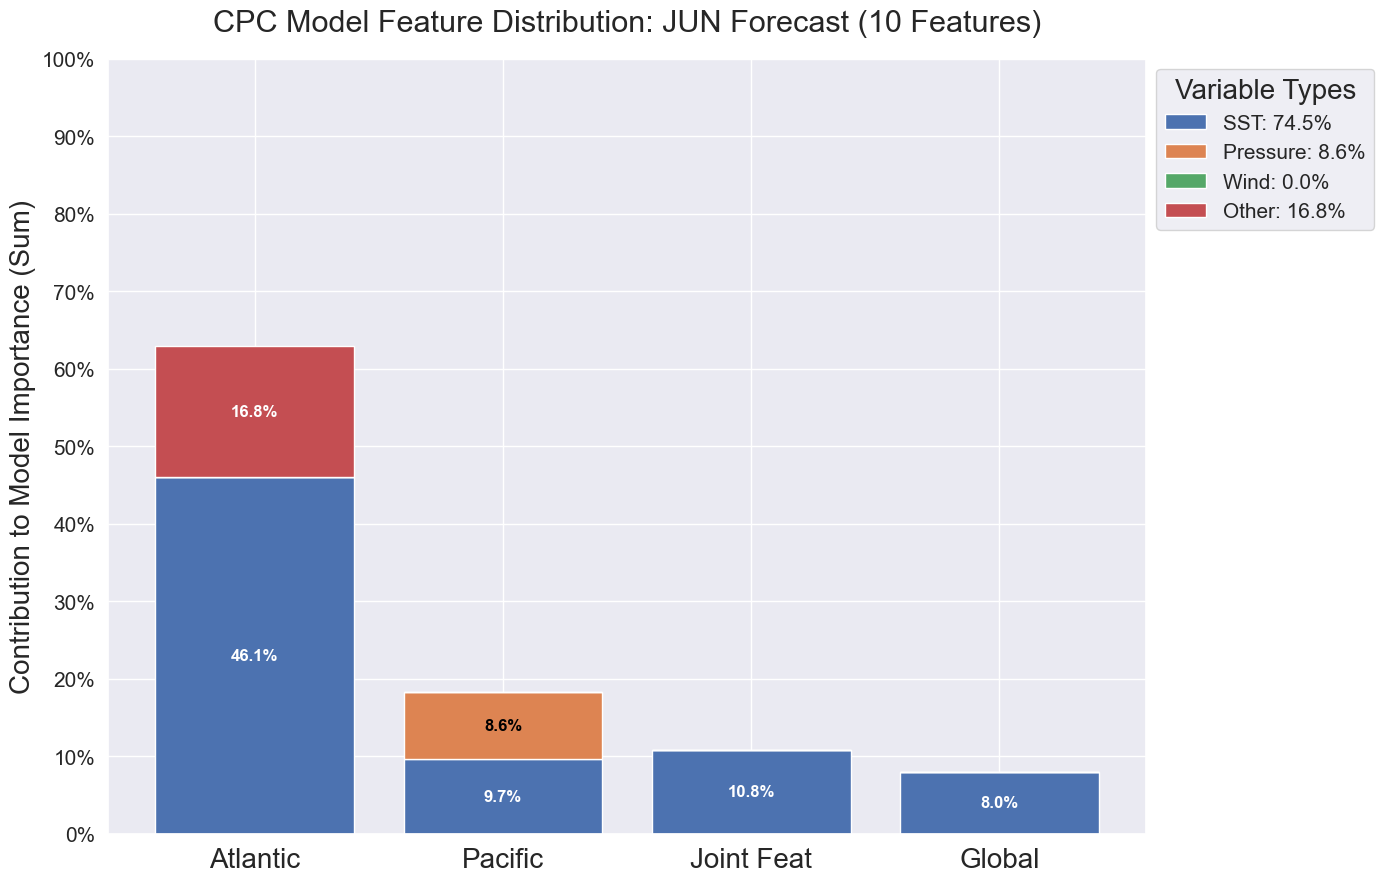

In [328]:
for i in range(7):
    print(i)
    z=plot_feature_distribution(i, importance_data, class_type)